<a href="https://colab.research.google.com/github/Gh4n5kH/mugni-data-science-2024/blob/main/Pertemuan13_Mugni_240401010355.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Muhamad Mugni Abdul Gani**

**NIM: 240401010355**

**Kelas: IF405**

==============================

**Langkah 1: Generate & Eksplorasi Dataset Non-Linear**

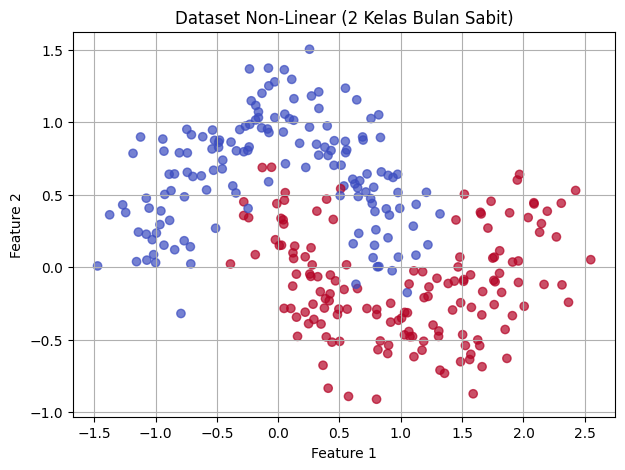

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset non-linear
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualisasi dataset
plt.figure(figsize=(7,5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

**Langkah 2: Bangun & Latih Neural Network Sederhana**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membagi data menjadi data latih dan data uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Membangun arsitektur Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Mengompilasi model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Menampilkan ringkasan model
model.summary()

# Melatih model
history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

**Langkah 3: Evaluasi & Visualisasi Kurva Belajar**

Akurasi pada data uji: 0.900


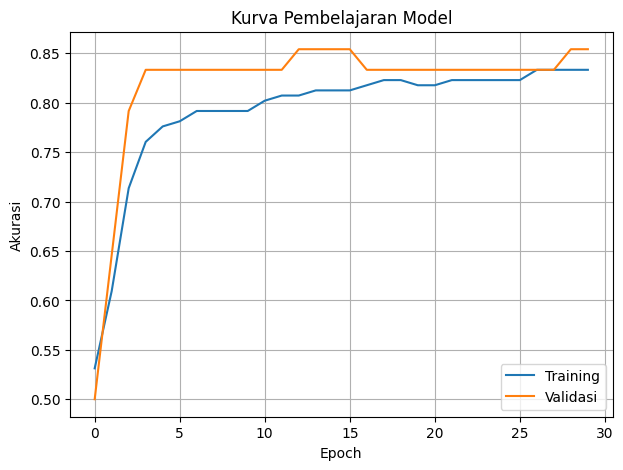

In [ ]:
import matplotlib.pyplot as plt

# Evaluasi model pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

# Plot akurasi training dan validasi
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')

plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Kurva Pembelajaran Model')
plt.legend()
plt.grid(True)

plt.show()

**Interpretasi**
- Model diuji menggunakan data yang belum pernah dilihat sebelumnya. Nilai akurasi menunjukkan seberapa baik model dalam mengklasifikasikan data tersebut.

- Dari kurva pembelajaran, jika akurasi training dan validasi saling mendekat, berarti model belajar dengan baik dan tidak mengalami overfitting. Sebaliknya, jika akurasi training jauh lebih tinggi daripada validasi, berarti model mulai menghafal data latih sehingga performanya pada data baru menurun (overfitting).

**Kesimpulan**

- Pada model ini, akurasi training dan validasi saling mendekat, sehingga model dapat mempelajari pola data dengan baik dan mampu memberikan prediksi yang baik pada data baru.

**Langkah 4: Siapkan Dataset Ulasan Produk**

In [ ]:
# Dataset ulasan produk
ulasan = [
    "Barangnya bagus banget, pengiriman cepat",
    "Kualitas jelek, tidak sesuai deskripsi",
    "Sangat puas, akan beli lagi",
    "Kecewa, barang rusak saat sampai",
    "Recommended, harga sesuai kualitas",
    "Buruk sekali, tidak sesuai ekspektasi",
    "Produknya berkualitas dan original",
    "Packing rapi dan aman",
    "Respon penjual sangat cepat",
    "Barang sesuai gambar",
    "Harga murah kualitas mantap",
    "Sangat memuaskan",
    "Pengiriman sangat cepat",
    "Barang berfungsi dengan baik",
    "Pelayanan ramah dan profesional",
    "Produk sangat bagus",
    "Senang dengan pembelian ini",
    "Kualitas premium sesuai harga",
    "Mantap, tidak mengecewakan",
    "Top, pasti beli lagi",
    "Barang cacat dan tidak bisa digunakan",
    "Pengiriman sangat lambat",
    "Sangat mengecewakan",
    "Produk palsu",
    "Tidak worth it",
    "Kualitas sangat buruk",
    "Packing rusak",
    "Barang tidak sesuai pesanan",
    "Ukuran tidak sesuai",
    "Pelayanan penjual buruk",
    "Warna berbeda dari gambar",
    "Produk cepat rusak",
    "Kecewa dengan kualitasnya",
    "Respon penjual lama",
    "Tidak direkomendasikan",
    "Banyak cacat pada produk",
    "Barang tidak lengkap",
    "Harga mahal kualitas jelek",
    "Pengalaman belanja buruk",
    "Sangat tidak puas"
]

# Label: 1 = Positif, 0 = Negatif
label = [
    1,0,1,0,1,0,
    1,1,1,1,1,1,1,1,1,1,1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]

# Menampilkan jumlah data
print("===================================")
print("Jumlah Ulasan :", len(ulasan))
print("Jumlah Label  :", len(label))
print("Positif       :", label.count(1))
print("Negatif       :", label.count(0))

Jumlah Ulasan : 40
Jumlah Label  : 40
Positif       : 17
Negatif       : 23


**Langkah 5: Ubah Teks Menjadi TF-IDF**

In [ ]:
import pandas as pd

# Menghitung total skor TF-IDF setiap kata
skor = X_text.sum(axis=0).A1
kata = tfidf.get_feature_names_out()

# Membuat DataFrame
df_tfidf = pd.DataFrame({
    'Kata': kata,
    'Skor TF-IDF': skor
})

# Mengurutkan dari skor terbesar
df_tfidf = df_tfidf.sort_values(by='Skor TF-IDF', ascending=False)

# Menampilkan 10 kata dengan skor tertinggi
print("\n10 Kata dengan Skor TF-IDF Tertinggi:")
print(df_tfidf.head(10))


10 Kata dengan Skor TF-IDF Tertinggi:
        Kata  Skor TF-IDF
64    sangat     4.090870
68     tidak     3.932391
67    sesuai     2.994804
30  kualitas     2.652736
6     barang     2.567404
53    produk     2.174396
14     buruk     2.080443
16     cepat     2.041469
25     harga     1.886922
61     rusak     1.696764


**Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Membagi data menjadi data latih dan data uji
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

# Membuat dan melatih model
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# Menghitung akurasi
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f"Akurasi model sentimen: {akurasi:.3f}")

# Menguji model dengan kalimat baru
kalimat_baru = ["Pelayanan sangat memuaskan dan ramah"]

pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print("Kalimat Baru :", kalimat_baru[0])
print("Prediksi     :", "Positif" if pred[0] == 1 else "Negatif")

Akurasi model sentimen: 0.375
Kalimat Baru : Pelayanan sangat memuaskan dan ramah
Prediksi     : Positif
